# Urban Pulse — Preprocessing Pipeline

Pipeline ini mengolah 4 CSV hasil ekstraksi fitur satelit (GEE) per kota
menjadi satu dataset bersih yang siap dipakai untuk training model
klasifikasi slum/non-slum (Random Forest / XGBoost).

**Input**: 4 CSV per kota (ambon, dki, kebumen, samarinda) di `data/raw_features/`

**Output**:
- `features_buildings_clean.csv` — dataset penuh + flag outlier
- `feature_columns.csv` — daftar kolom fitur yang aman dipakai model
- `random_split_train.csv` / `random_split_test.csv` — split 80/20 stratified
- `loco_fold_summary.csv` — ringkasan Leave-One-City-Out folds

**Catatan penting soal data leakage**: `slum_frac` adalah variabel yang
dipakai untuk MEMBUAT label `slum` (slum = 1 if slum_frac > threshold).
Kolom ini **tidak boleh** dipakai sebagai fitur model karena itu kebocoran
label langsung. Begitu juga `kumuh_lvl` (turunan severity dari label).

## Referensi akademik

Pemilihan fitur dan pendekatan pada notebook ini merujuk pada literatur
berikut:

- **NDBI (Normalized Difference Built-up Index)**: Zha, Y., Gao, J., & Ni, S.
  (2003). Use of normalized difference built-up index in automatically
  mapping urban areas from TM imagery. *International Journal of Remote
  Sensing*, 24(3), 583–594. https://doi.org/10.1080/01431160304987
- **Tekstur GLCM (Gray-Level Co-occurrence Matrix)**: Haralick, R. M.,
  Shanmugam, K., & Dinstein, I. (1973). Textural features for image
  classification. *IEEE Transactions on Systems, Man, and Cybernetics*,
  SMC-3(6), 610–621.
- **GLCM variance/contrast untuk slum mapping**: Kuffer, M., Pfeffer, K.,
  Sliuzas, R., & Baud, I. (2016). Extraction of slum areas from VHR
  imagery using GLCM variance. *IEEE Journal of Selected Topics in Applied
  Earth Observations and Remote Sensing*, 9(5), 1830–1840.
- **Random Forest & SVM untuk slum mapping di Indonesia**: Leonita, G.,
  Kuffer, M., Sliuzas, R., & Persello, C. (2018). Machine learning-based
  slum mapping in support of slum upgrading programs: The case of Bandung
  City, Indonesia. *Remote Sensing*, 10(10), 1522.
  https://doi.org/10.3390/rs10101522 — studi ini secara langsung relevan
  karena dilakukan di Indonesia dan membandingkan algoritma tree-based
  dengan SVM untuk masalah yang setara.
- **Karakteristik fisik permukiman kumuh** (ukuran bangunan kecil,
  kepadatan atap tinggi, minim ruang hijau, pola organik tidak teratur)
  yang menjadi dasar fitur interaksi pada Bagian 3: Machine
  Learning-Based Local Knowledge Approach to Mapping Urban Slums in
  Bandung City, Indonesia (2024). *Urban Science*, 8(4), 189.
  https://doi.org/10.3390/urbansci8040189
- **Sentinel-1 SAR untuk deteksi area terbangun** (dasar penggunaan
  VV/VH/rasio VV-VH): backscatter SAR yang lebih tinggi pada area
  terbangun disebabkan oleh efek pemantulan ganda (double-bounce) dari
  struktur bangunan — lihat ulasan pada *ScienceDirect* (2022),
  "Unsupervised domain adaptation for global urban extraction using
  Sentinel-1 SAR and Sentinel-2 MSI data", dan Koppel, K., Zalite, K.,
  Voormansik, K., & Jagdhuber, T. (2017). Sensitivity of Sentinel-1
  backscatter to characteristics of buildings. *International Journal of
  Remote Sensing*, 38(22), 6298–6318.

In [1]:
from __future__ import annotations  # izinkan type hint modern (list[str], dst) di Python versi lama

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)  # tampilkan semua kolom saat print dataframe, jangan dipotong
pd.set_option("display.width", 200)         # lebar tampilan tabel di terminal/output

## 0. Konfigurasi

In [2]:
RAW_DIR = Path("data/raw_features")          # lokasi 4 csv hasil GEE
OUT_DIR = Path("data/processed")             # lokasi output pipeline ini
GEOJSON_PATH = Path("data/raw_features/labels.geojson")  # geometri asli untuk peta sebaran (opsional)

CITY_FILES = {
    "ambon": "features_ambon.csv",
    "dki": "features_dki.csv",
    "kebumen": "features_kebumen.csv",
    "samarinda": "features_samarinda.csv",
}

# Kolom yang BUKAN fitur model (identitas, metadata, sumber label)
ID_COLS = ["unit_id", "unit_name", "city"]
LEAKAGE_COLS = ["slum_frac", "kumuh_lvl"]   # turunan langsung dari label
TARGET_COL = "slum"

OUT_DIR.mkdir(parents=True, exist_ok=True)  # buat folder output jika belum ada, tidak error jika sudah ada

## 1. Load & gabung 4 CSV per kota

In [3]:
def load_and_combine(raw_dir: Path = RAW_DIR) -> pd.DataFrame:
    """Baca 4 CSV per kota dan gabung jadi satu dataframe."""
    frames = []
    for city, fname in CITY_FILES.items():
        path = raw_dir / fname
        if not path.exists():
            raise FileNotFoundError(
                f"File tidak ditemukan: {path}. "
                f"Pastikan 4 CSV hasil export GEE ada di {raw_dir}/"
            )
        df = pd.read_csv(path)
        mismatched = df["city"].unique().tolist()
        if mismatched != [city]:
            print(f"  PERINGATAN: file {fname} punya nilai city={mismatched}, "
                  f"diharapkan ['{city}']")
        frames.append(df)

    full = pd.concat(frames, ignore_index=True)
    return full

In [4]:
df = load_and_combine()
print(f"Loaded: {df.shape}")
df_raw_snapshot = df.copy()  # disimpan untuk perbandingan visual mentah vs olahan (Bagian 10)
df.head()

Loaded: (830, 40)


,unit_id,unit_name,city,area_m2,slum_frac,slum,kumuh_lvl,ndvi_mean,ndvi_stdDev,ndbi_mean,ndbi_stdDev,bsi_mean,bsi_stdDev,brightness_mean,brightness_stdDev,ndbi_contrast_mean,ndbi_contrast_stdDev,ndbi_ent_mean,ndbi_ent_stdDev,ndbi_var_mean,ndbi_var_stdDev,VV_mean,VV_stdDev,VH_mean,VH_stdDev,vv_vh_mean,vv_vh_stdDev,building_fractional_count_mean,building_fractional_count_stdDev,building_height_mean,building_height_stdDev,building_presence_mean,building_presence_stdDev,b_count,b_area_sum,b_area_mean,b_area_std,b_area_median,b_coverage,b_density_km2
0,ambon_0010,Kel. Nusaniwe,ambon,7.940114e+05,5.855250e-07,0,Non-Slum,0.487045,0.269449,-0.078539,0.202114,-0.063228,0.176690,0.076263,0.037864,21.538693,15.635619,3.895083,0.320703,23.749267,18.241799,-4.418654,5.046813,-11.322962,4.757619,6.904308,1.903798,0.001127,0.001282,2.382818,2.528127,0.264990,0.271335,2809,251328.396442,89.472551,104.075277,67.967874,0.316530,3537.732498
1,ambon_0014,Batu Gajah,ambon,9.071218e+05,1.427713e-06,0,Non-Slum,0.645361,0.225274,-0.188654,0.164789,-0.158986,0.151993,0.061798,0.029881,16.551814,8.773487,3.847005,0.333826,22.684804,15.683648,-4.503816,4.335795,-11.495758,3.993699,6.991942,1.698211,0.000756,0.001178,1.770419,2.732339,0.157684,0.227981,2129,172610.313076,81.075769,82.825071,59.893860,0.190284,2346.983655
2,ambon_0031,Soya,ambon,1.873981e+07,8.884873e-08,0,Non-Slum,0.825217,0.092984,-0.339541,0.089946,-0.307827,0.089834,0.039247,0.014070,5.060636,4.934592,3.196920,0.429797,4.882902,7.749100,-7.596862,2.994648,-14.242953,2.745832,6.646091,0.879520,0.000067,0.000392,0.168516,0.959842,0.015020,0.081390,3734,327906.506330,87.816418,80.778897,68.087399,0.017498,199.254924
3,ambon_0000,Latuhalat,ambon,5.472411e+06,0.000000e+00,0,Non-Slum,0.731300,0.165339,-0.311867,0.121469,-0.267184,0.120729,0.053437,0.022589,10.720499,8.790634,3.583898,0.438690,13.492574,12.589486,-5.953850,4.558175,-12.538977,4.415892,6.585127,1.326758,0.000252,0.000722,0.567279,1.447913,0.059574,0.154134,4161,349282.215436,83.941893,74.015210,67.791976,0.063826,760.359618
4,ambon_0001,Seilale,ambon,1.119819e+06,0.000000e+00,0,Non-Slum,0.754344,0.157801,-0.320285,0.116961,-0.280415,0.114812,0.050319,0.019741,12.243834,12.892068,3.612480,0.392031,14.567568,16.499601,-7.058875,4.295956,-13.574299,4.062710,6.515424,1.100340,0.000241,0.000716,0.499721,1.346449,0.055099,0.149587,863,68421.134840,79.282891,76.681424,59.188367,0.061100,770.660205


## 2. Validasi kualitas data

Cek duplikat `unit_id`, missing values di kolom fitur, dan distribusi
kelas per kota (penting karena dataset ini *imbalanced* dan proporsinya
bervariasi cukup besar antar kota).

In [5]:
def validate(df: pd.DataFrame) -> None:
    n_dup = df.duplicated(subset=["unit_id"]).sum()
    if n_dup:
        raise ValueError(f"Ditemukan {n_dup} unit_id duplikat — cek ulang sumber data.")

    feature_cols = [c for c in df.columns if c not in ID_COLS + LEAKAGE_COLS + [TARGET_COL]]
    na_counts = df[feature_cols].isna().sum()
    na_counts = na_counts[na_counts > 0]
    if len(na_counts):
        print("  PERINGATAN: ada missing values di kolom fitur:")
        print(na_counts)
    else:
        print("  OK: tidak ada missing values di kolom fitur numerik.")

    print("\n  Distribusi kelas per kota:")
    ct = df.groupby("city")[TARGET_COL].value_counts().unstack(fill_value=0)
    ct["total"] = ct.sum(axis=1)
    ct["pct_slum"] = (ct.get(1, 0) / ct["total"] * 100).round(1)
    print(ct.to_string())
    print(f"\n  Total: {len(df)} unit | slum={int(df[TARGET_COL].sum())} "
          f"({df[TARGET_COL].mean()*100:.1f}%)")

In [6]:
validate(df)

  OK: tidak ada missing values di kolom fitur numerik.

  Distribusi kelas per kota:
slum         0   1  total  pct_slum
city                               
ambon       35  15     50      30.0
dki        199  62    261      23.8
kebumen    433  27    460       5.9
samarinda   45  14     59      23.7

  Total: 830 unit | slum=118 (14.2%)


## 3. Statistik deskriptif fitur numerik

Sekadar eyeball cepat — tree-based model tidak butuh fitur ter-scale,
tapi tetap penting untuk lihat rentang nilai & deteksi anomali kasar.

In [7]:
num_cols = df.select_dtypes(include="number").columns.tolist()
num_cols = [c for c in num_cols if c != TARGET_COL]
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
area_m2,830.0,3.598309e+06,6.049728e+06,15471.634228,1.340392e+06,2.121931e+06,3.675368e+06,7.249199e+07
slum_frac,830.0,2.139742e-02,8.202120e-02,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,9.216497e-01
ndvi_mean,830.0,4.721340e-01,2.120571e-01,-0.012611,2.706269e-01,5.200067e-01,6.305189e-01,8.494202e-01
ndvi_stdDev,830.0,1.641447e-01,5.881802e-02,0.052739,1.236278e-01,1.527302e-01,1.929181e-01,4.648985e-01
ndbi_mean,830.0,-8.478947e-02,1.437597e-01,-0.392107,-1.966925e-01,-1.112459e-01,5.442843e-02,1.959940e-01
ndbi_stdDev,830.0,1.198246e-01,3.069754e-02,0.057200,9.871764e-02,1.136384e-01,1.376474e-01,2.947922e-01
bsi_mean,830.0,-5.033134e-02,1.267990e-01,-0.356699,-1.413664e-01,-6.126514e-02,7.042649e-02,1.804437e-01
bsi_stdDev,830.0,1.055362e-01,2.222202e-02,0.047632,9.041526e-02,1.041017e-01,1.179867e-01,1.828965e-01
brightness_mean,830.0,8.039029e-02,2.747687e-02,0.032673,6.057172e-02,7.234375e-02,1.035238e-01,1.572360e-01
brightness_stdDev,830.0,2.727678e-02,1.331514e-02,0.006822,1.560574e-02,2.228499e-02,3.788256e-02,8.363172e-02


## 4. Feature engineering tambahan

Fitur interaksi yang relevan secara domain untuk permukiman kumuh:
padat, kecil, rendah, tidak teratur, minim vegetasi, tekstur kasar.
Semua dihitung dari kolom yang sudah ada, jadi tidak menambah leakage baru.

Karakteristik fisik ini merujuk pada temuan studi slum mapping di Bandung,
Indonesia (Urban Science, 2024, https://doi.org/10.3390/urbansci8040189),
yang mengidentifikasi ukuran bangunan kecil, kepadatan atap/bangunan
tinggi, minimnya ruang hijau, dan pola permukiman organik (tidak teratur)
sebagai indikator fisik permukiman kumuh yang konsisten teramati di
berbagai studi sejenis.

In [8]:
def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    eps = 1e-9  # hindari pembagian nol

    # Built-up minus greenery: makin tinggi makin "built-up dominant" dgn sedikit hijau
    df["built_minus_green"] = df["ndbi_mean"] - df["ndvi_mean"]

    # Rasio tekstur terhadap built-up: tekstur kasar relatif terhadap intensitas built-up
    df["texture_to_built_ratio"] = df["ndbi_contrast_mean"] / (df["ndbi_mean"].abs() + eps)

    # Dominasi bangunan kecil: rasio area median terhadap rata-rata
    df["small_building_dominance"] = df["b_area_median"] / (df["b_area_mean"] + eps)

    # Dense low-rise pattern: kepadatan tinggi tapi tinggi bangunan rendah
    df["dense_lowrise"] = df["b_density_km2"] / (df["building_height_mean"] + eps)

    # Packing tightness: banyak bangunan kecil dalam area sempit
    df["packing_tightness"] = df["b_count"] / (df["b_area_mean"] + eps)

    # Variabilitas ukuran bangunan (coefficient of variation)
    df["b_size_cv"] = df["b_area_std"] / (df["b_area_mean"] + eps)

    # SAR roughness relatif terhadap built-up
    df["sar_built_interaction"] = df["vv_vh_mean"] * df["ndbi_mean"]

    return df

In [9]:
df = add_engineered_features(df)
new_cols = ["built_minus_green", "texture_to_built_ratio", "small_building_dominance",
            "dense_lowrise", "packing_tightness", "b_size_cv", "sar_built_interaction"]
print(f"Ditambahkan {len(new_cols)} fitur interaksi:")
df[new_cols].describe().T

Ditambahkan 7 fitur interaksi:


,count,mean,std,min,25%,50%,75%,max
built_minus_green,830.0,-0.556924,0.352283,-1.229828,-0.817965,-0.639385,-0.208957,0.113477
texture_to_built_ratio,830.0,403.267445,2348.888660,11.680115,48.304528,85.206524,210.696411,45283.543208
small_building_dominance,830.0,0.785953,0.139962,0.152182,0.715207,0.827640,0.891127,1.114564
dense_lowrise,830.0,1281.101499,341.976666,117.880261,1082.703622,1329.747459,1520.722446,2054.891874
packing_tightness,830.0,39.229158,44.660222,0.648594,12.384468,20.785878,44.521498,299.017498
b_size_cv,830.0,1.206413,0.719647,0.591788,0.752428,0.961342,1.395839,6.085173
sar_built_interaction,830.0,-0.547833,0.998600,-2.718542,-1.339624,-0.771036,0.366674,1.851736


## 5. Pemisahan kolom: identitas vs fitur vs target

`slum_frac` dan `kumuh_lvl` dikeluarkan dari fitur model karena keduanya
turunan langsung dari label (data leakage).

In [10]:
def get_feature_columns(df: pd.DataFrame) -> list[str]:
    """Daftar kolom yang aman dipakai sebagai fitur model (numerik, non-leakage)."""
    exclude = set(ID_COLS + LEAKAGE_COLS + [TARGET_COL])
    cols = [c for c in df.columns if c not in exclude]
    non_numeric = [c for c in cols if not pd.api.types.is_numeric_dtype(df[c])]
    if non_numeric:
        raise ValueError(f"Kolom fitur non-numerik terdeteksi (perlu encoding manual): {non_numeric}")
    return cols

In [11]:
feature_cols = get_feature_columns(df)
print(f"Total kolom fitur model: {len(feature_cols)}")
print(f"Kolom dibuang dari fitur (leakage/identitas): {ID_COLS + LEAKAGE_COLS}")
feature_cols

Total kolom fitur model: 41
Kolom dibuang dari fitur (leakage/identitas): ['unit_id', 'unit_name', 'city', 'slum_frac', 'kumuh_lvl']


['area_m2',
 'ndvi_mean',
 'ndvi_stdDev',
 'ndbi_mean',
 'ndbi_stdDev',
 'bsi_mean',
 'bsi_stdDev',
 'brightness_mean',
 'brightness_stdDev',
 'ndbi_contrast_mean',
 'ndbi_contrast_stdDev',
 'ndbi_ent_mean',
 'ndbi_ent_stdDev',
 'ndbi_var_mean',
 'ndbi_var_stdDev',
 'VV_mean',
 'VV_stdDev',
 'VH_mean',
 'VH_stdDev',
 'vv_vh_mean',
 'vv_vh_stdDev',
 'building_fractional_count_mean',
 'building_fractional_count_stdDev',
 'building_height_mean',
 'building_height_stdDev',
 'building_presence_mean',
 'building_presence_stdDev',
 'b_count',
 'b_area_sum',
 'b_area_mean',
 'b_area_std',
 'b_area_median',
 'b_coverage',
 'b_density_km2',
 'built_minus_green',
 'texture_to_built_ratio',
 'small_building_dominance',
 'dense_lowrise',
 'packing_tightness',
 'b_size_cv',
 'sar_built_interaction']

## 6. Deteksi outlier (flag only)

Tree-based model tahan terhadap outlier, jadi baris **tidak dihapus**
otomatis — hanya diberi flag untuk inspeksi manual / opsi exclude saat
training kalau memang perlu.

In [12]:
def flag_outliers(df: pd.DataFrame, feature_cols: list[str], z_thresh: float = 4.0) -> pd.DataFrame:
    df = df.copy()
    z = (df[feature_cols] - df[feature_cols].mean()) / df[feature_cols].std()
    df["_n_outlier_features"] = (z.abs() > z_thresh).sum(axis=1)
    df["_is_outlier"] = df["_n_outlier_features"] > 0
    return df

In [13]:
df = flag_outliers(df, feature_cols)
n_outlier = int(df["_is_outlier"].sum())
print(f"{n_outlier} unit terflag punya >=1 fitur dengan |z-score| > 4")
df.loc[df["_is_outlier"], ["unit_id", "city", TARGET_COL, "_n_outlier_features"]] \
    .sort_values("_n_outlier_features", ascending=False).head(10)

73 unit terflag punya >=1 fitur dengan |z-score| > 4


,unit_id,city,slum,_n_outlier_features
196,dki_0169,dki,0,3
796,samarinda_0023,samarinda,0,3
281,dki_0151,dki,1,3
785,samarinda_0007,samarinda,0,3
157,dki_0092,dki,0,3
214,dki_0201,dki,0,3
799,samarinda_0026,samarinda,0,3
135,dki_0058,dki,0,3
81,dki_0207,dki,0,3
133,dki_0054,dki,0,3


### 6.1 Detail fitur mana yang outlier (per baris)

`_n_outlier_features` di atas hanya memberi **hitungan**, belum
menyebutkan **fitur mana** yang sebenarnya bermasalah. Fungsi di bawah
ini membongkar detail itu untuk satu baris tertentu — fitur apa yang
melewati ambang, seberapa jauh (z-score), dan berapa nilai aslinya.

In [14]:
def explain_outlier_row(df: pd.DataFrame, feature_cols: list[str], row_index,
                         z_thresh: float = 4.0) -> pd.DataFrame:
    """Tunjukkan fitur mana saja yang outlier pada satu baris tertentu,
    diurutkan dari yang paling ekstrem."""
    z = (df[feature_cols] - df[feature_cols].mean()) / df[feature_cols].std()
    z_row = z.loc[row_index]
    flagged = z_row[z_row.abs() > z_thresh].sort_values(key=lambda s: s.abs(), ascending=False)

    return pd.DataFrame({
        "feature": flagged.index,
        "z_score": flagged.values.round(2),
        "nilai_asli": df.loc[row_index, flagged.index].values,
    })

In [15]:
# Contoh: bongkar detail baris dengan jumlah outlier terbanyak
contoh_idx = df.loc[df["_is_outlier"]].sort_values("_n_outlier_features", ascending=False).index[0]
print(f"Detail outlier untuk: {df.loc[contoh_idx, 'unit_id']} ({df.loc[contoh_idx, 'city']})")
explain_outlier_row(df, feature_cols, contoh_idx)

Detail outlier untuk: dki_0169 (dki)


,feature,z_score,nilai_asli
0,packing_tightness,5.43,281.811392
1,b_count,4.88,27489
2,b_area_sum,4.07,2681385.997137


Gunakan `explain_outlier_row(df, feature_cols, <row_index>)` untuk baris
manapun yang ingin diperiksa lebih lanjut — misalnya untuk memutuskan
apakah suatu unit perlu diperiksa ulang datanya, atau memang valid tapi
kebetulan ekstrem (contoh: kelurahan yang sangat luas, atau kawasan
komersial dengan satu bangunan raksasa yang mendominasi statistik luas
bangunan).

## 7. Simpan output

Dataset bersih dan daftar fitur final disimpan di sini untuk dipakai
oleh `modeling.ipynb`. Pembagian LOCO dan random split **tidak**
disiapkan di notebook ini — keduanya dihitung langsung di
`modeling.ipynb` karena di situlah satu-satunya tempat pembagian itu
benar-benar dipakai untuk melatih dan mengevaluasi model. Menyiapkannya
di sini hanya akan jadi duplikasi perhitungan yang tidak terpakai.

In [16]:
# Dataset bersih lengkap (semua kolom termasuk identitas, leakage cols disimpan utk referensi)
df.to_csv(OUT_DIR / "features_buildings_clean.csv", index=False)
print(f"-> {OUT_DIR / 'features_buildings_clean.csv'} (dataset penuh + flag outlier)")

# Daftar kolom fitur final (dipakai modul training nanti)
pd.Series(feature_cols, name="feature_name").to_csv(
    OUT_DIR / "feature_columns.csv", index=False)
print(f"-> {OUT_DIR / 'feature_columns.csv'} (daftar {len(feature_cols)} kolom fitur)")

print("\nSelesai. Dataset siap dipakai untuk training model (XGBoost) "
      "di modeling.ipynb.")

-> data\processed\features_buildings_clean.csv (dataset penuh + flag outlier)
-> data\processed\feature_columns.csv (daftar 41 kolom fitur)

Selesai. Dataset siap dipakai untuk training model (XGBoost) di modeling.ipynb.


## 8. Visualisasi — Data Mentah vs Data Olahan

Tiga jenis visualisasi, ditampilkan langsung inline di notebook (tidak
disimpan sebagai file gambar terpisah):
1. **Distribusi fitur** — histogram sebelum vs sesudah feature engineering
2. **Korelasi dengan label** — fitur mentah vs fitur (mentah + rekayasa)
3. **Peta sebaran** — lokasi geografis kelurahan per kota, diwarnai slum/non-slum

### 8.1 Distribusi fitur — sebelum vs sesudah feature engineering

Fitur mentah ditampilkan berdampingan dengan fitur hasil rekayasa
(Bagian 4) yang berasal darinya, untuk melihat bagaimana proses
kombinasi mengubah bentuk distribusinya.

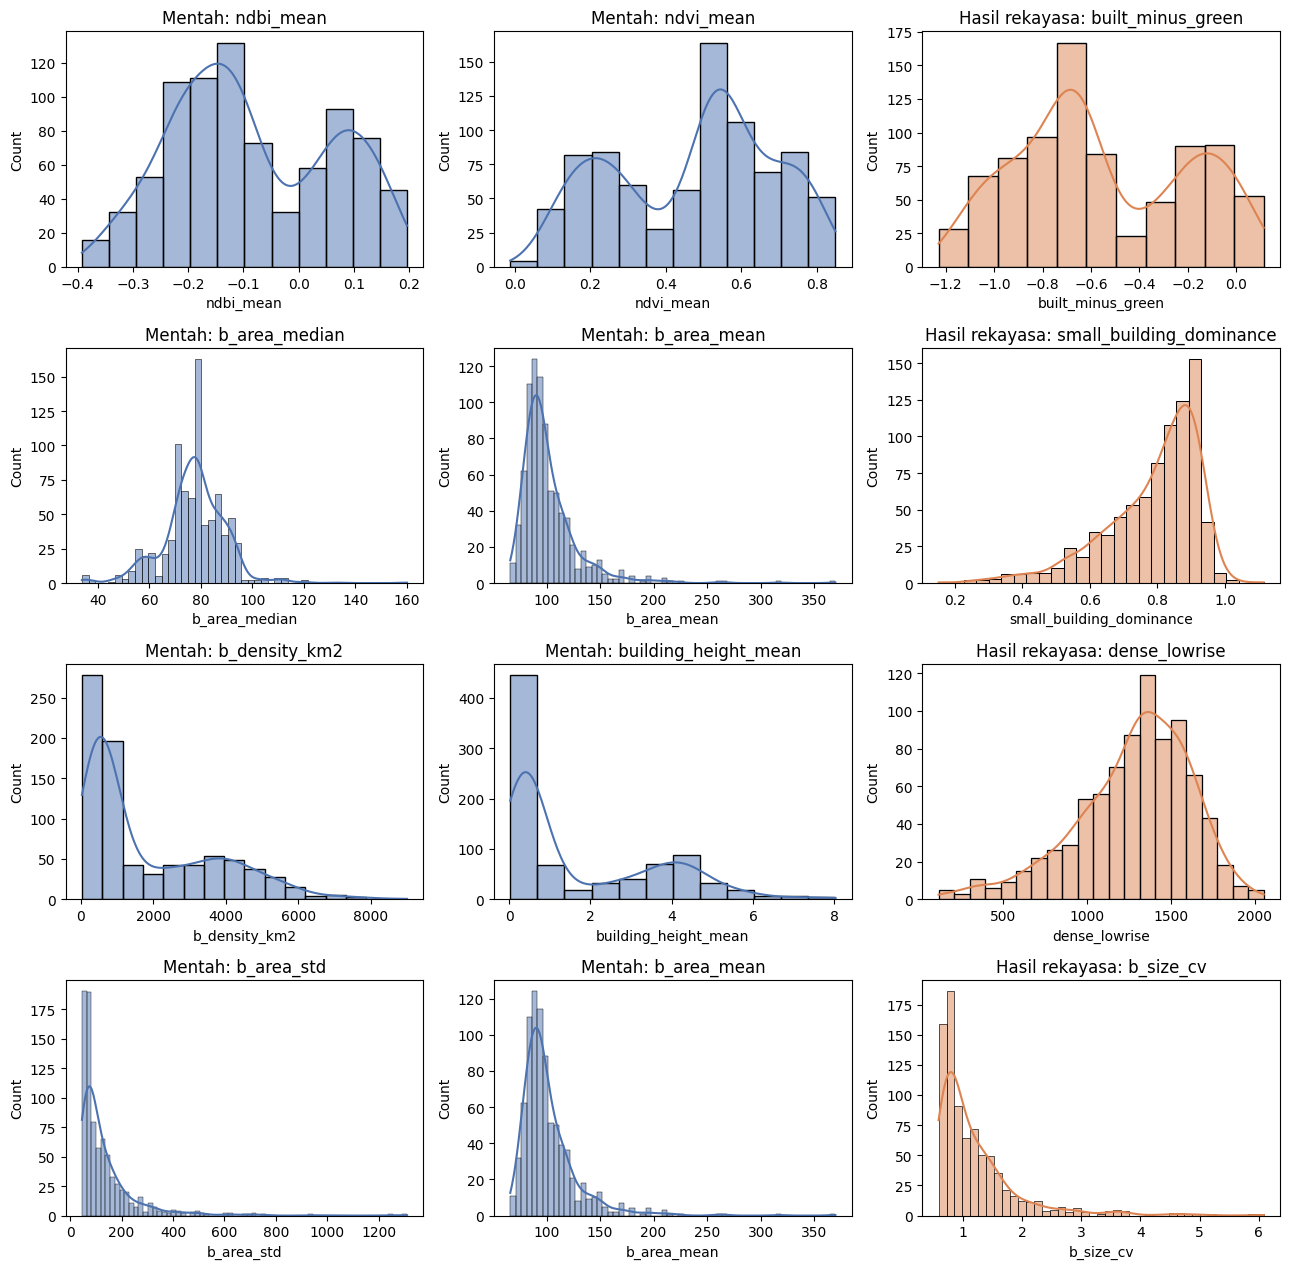

In [17]:
# Pasangan (fitur mentah, fitur hasil rekayasa yang dibangun darinya)
pairs_to_compare = [
    (["ndbi_mean", "ndvi_mean"], "built_minus_green"),
    (["b_area_median", "b_area_mean"], "small_building_dominance"),
    (["b_density_km2", "building_height_mean"], "dense_lowrise"),
    (["b_area_std", "b_area_mean"], "b_size_cv"),
]

# Buat grid subplot: 1 baris per pasangan, 3 kolom (2 fitur mentah + 1 hasil rekayasa)
fig, axes = plt.subplots(len(pairs_to_compare), 3, figsize=(13, 3.2 * len(pairs_to_compare)))

for row, (raw_feats, engineered_feat) in enumerate(pairs_to_compare):
    # Kolom kiri & tengah: histogram tiap fitur MENTAH yang jadi bahan baku
    for col, raw_feat in enumerate(raw_feats):
        sns.histplot(df_raw_snapshot[raw_feat], kde=True, ax=axes[row, col], color="#4C72B0")
        axes[row, col].set_title(f"Mentah: {raw_feat}")
    # Kolom kanan: histogram fitur HASIL REKAYASA dari kombinasi 2 fitur mentah tersebut
    sns.histplot(df[engineered_feat], kde=True, ax=axes[row, 2], color="#DD8452")
    axes[row, 2].set_title(f"Hasil rekayasa: {engineered_feat}")

plt.tight_layout()
plt.show()

### 8.2 Korelasi dengan label — fitur mentah vs fitur lengkap

Membandingkan ranking korelasi (Pearson, terhadap label `slum`) sebelum
dan sesudah 7 fitur rekayasa ditambahkan — untuk melihat apakah fitur
baru tersebut masuk ke jajaran fitur yang relevan, atau tidak banyak
menambah informasi baru.

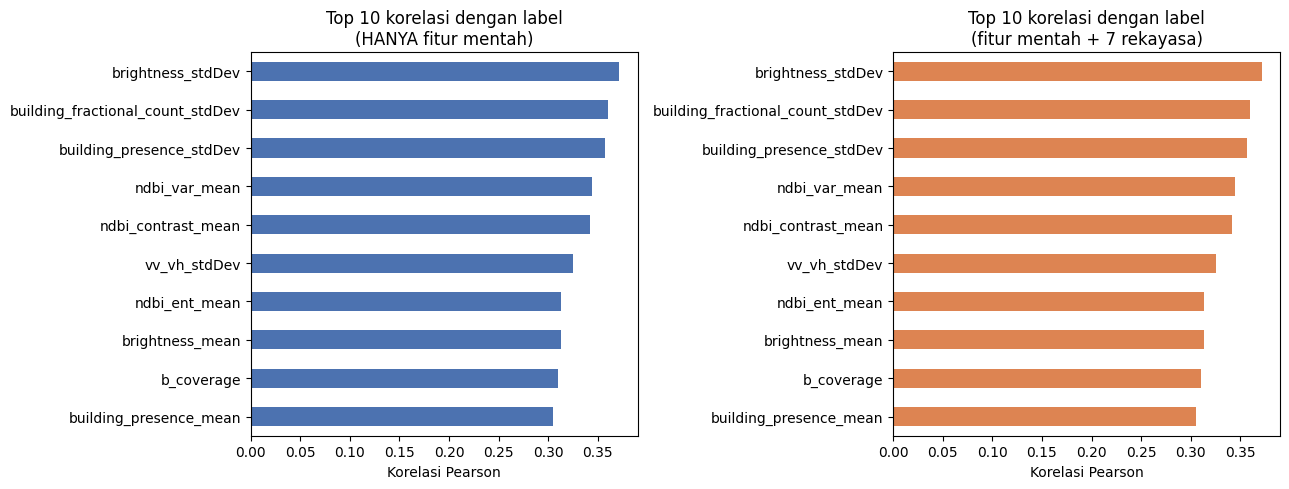

In [18]:
# Daftar fitur TANPA 7 fitur rekayasa, untuk dibandingkan dengan daftar fitur lengkap
raw_feature_cols = [c for c in feature_cols if c not in
                     ["built_minus_green", "texture_to_built_ratio", "small_building_dominance",
                      "dense_lowrise", "packing_tightness", "b_size_cv", "sar_built_interaction"]]

# Hitung korelasi Pearson tiap fitur terhadap label slum, untuk kedua skenario
corr_raw = df[raw_feature_cols + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)
corr_full = df[feature_cols + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)

# Ambil 10 fitur dengan korelasi absolut tertinggi (boleh positif atau negatif)
top_raw = corr_raw.reindex(corr_raw.abs().sort_values(ascending=False).index).head(10)
top_full = corr_full.reindex(corr_full.abs().sort_values(ascending=False).index).head(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# Panel kiri: ranking korelasi HANYA dari 34 fitur mentah
top_raw.sort_values().plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Top 10 korelasi dengan label\n(HANYA fitur mentah)")
axes[0].set_xlabel("Korelasi Pearson")

# Panel kanan: ranking korelasi dari fitur mentah + 7 fitur rekayasa
top_full.sort_values().plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].set_title("Top 10 korelasi dengan label\n(fitur mentah + 7 rekayasa)")
axes[1].set_xlabel("Korelasi Pearson")

plt.tight_layout()
plt.show()

Jika ada fitur rekayasa (misal `built_minus_green`, `dense_lowrise`,
dst.) yang muncul di panel kanan padahal tidak ada di panel kiri, itu
tanda fitur tersebut membawa sinyal yang tidak tertangkap fitur mentah
secara individual — justifikasi konkret bahwa Bagian 4 (feature
engineering) memberi nilai tambah, bukan sekadar duplikasi informasi.

**Catatan jujur dari hasil di atas**: pada dataset ini, top-10 korelasi
Pearson kedua panel ternyata identik — belum ada fitur rekayasa yang
masuk ke jajaran 10 teratas berdasarkan korelasi linear sederhana. Ini
tidak berarti Bagian 4 tidak berguna; korelasi Pearson hanya menangkap
hubungan **linear**, sedangkan tree-based model (Random Forest/XGBoost)
dapat memanfaatkan fitur rekayasa lewat interaksi non-linear yang tidak
tertangkap ukuran korelasi ini. Hasil SHAP pada `modeling.ipynb` adalah
ukuran yang lebih relevan untuk menilai kontribusi sesungguhnya fitur
rekayasa terhadap model, bukan korelasi sederhana di sini.